

## 📘 DATA DICTIONARY (KAMUS DATA)
> **Fungsi Dataset:** Menjadi basis data pelatihan (*training*) dan validasi (*testing*) algoritma Machine Learning guna mengenali pola teks mutasi bank Indonesia.

| Nama Kolom | Tipe Data | Deskripsi / Arti Kolom | Aturan / Batasan Bisnis | Contoh Nilai |
| :--- | :--- | :--- | :--- | :--- |
| `transaction_name` | String / Object | Deskripsi teks transaksi finansial global yang telah dilokalisasi ke format mutasi perbankan Indonesia dan diberi augmentasi data (*leetspeak/prefix*). | Maksimal 255 karakter, telah melalui proses penyaringan derau tekstual. | `M-BCA TOKOPEDIA*MEMO - <ID>` |
| `amount` | Float | Nilai nominal transaksi dalam Rupiah (IDR) yang digenerate acak berbasis batas logis per kategori. | Nilai wajib positif ( $> 0$ ), tidak boleh bernilai kosong (*NaN*). | `634920.0` |
| `category` | String / Object | Label kelompok sektor pengeluaran finansial dalam bahasa Indonesia formal (Target Class). | Terbatas pada 5 kategori: *Makanan & Minuman, Transport, Belanja, Hiburan, Tagihan*. | `Belanja` |
| `category_encoded` | Integer | Transformasi angka indeks dari kolom kategori hasil proses *Label Encoding* agar siap diproses oleh algoritma AI. | Rentang nilai berupa angka bulat positif antara `0` sampai `4`. | `0` |

---

## 🎯 PERTANYAAN BISNIS (SMART CRITERIA)

Sebelum melangkah ke tahap pelatihan model Machine Learning, pipeline penyiapan data ini dikendalikan oleh satu pertanyaan bisnis utama:

### ❓ Pertanyaan Utama:
**"Bagaimana efektivitas kombinasi teknik Synthetic Oversampling dan Force Under-sampling dalam mendistribusikan data secara seimbang dengan target kuota tepat 20% (1.200 baris) per kategori sebelum model klasifikasi dilatih?"**

### 🔍 Breakdown SMART Kriteria:
* **Specific (S):** Fokus menguji keseimbangan distribusi jumlah baris data pada 5 kategori target (*Makanan & Minuman, Transport, Belanja, Hiburan, Tagihan*).
* **Measurable (M):** Diukur secara eksak menggunakan fungsi hitung frekuensi `.value_counts()`. Target keberhasilan adalah jika setiap kategori bernilai tepat 1.200 baris (tidak kurang dan tidak lebih).
* **Achievable (A):** Sangat mungkin dicapai dengan memanfaatkan fungsionalitas generator teks tiruan dan fungsi `.sample(n=1200)` pada pustaka Pandas.
* **Relevant (R):** Sangat relevan karena ketidakseimbangan kelas (*imbalanced data*) dapat menyebabkan model AI mengalami bias (hanya pintar menebak kelas mayoritas). Penyetaraan ini menjamin akurasi model yang objektif.
* **Time-bound (T):** Target pemenuhan kuota distribusi data seimbang ini wajib terpenuhi dan terverifikasi pada akhir eksekusi pipeline data latih ini.

# Cell 1A: Inisialisasi Environment & Pengumpulan Data Latih (Data Collection)

### 🎯 Fungsi Utama Cell
Cell ini berfungsi sebagai gerbang utama *data pipeline* untuk memuat pustaka analisis data, mengamankan jalur penyimpanan berkas (*robust path resolution*), serta memuat dataset mentah finansial ke dalam memori Python.

### ⚙️ Alur Proses Logis:
1. **Library Ingestion:** Memuat modul inti manipulasi data (`pandas`, `numpy`), transformasi label (`sklearn`), ekspresi reguler (`re`), dan generator pengacakan (`random`).
2. **Robust Path Resolution (`pathlib`):** Mengamankan jalur akses berkas menggunakan path absolut sistem guna menghindari risiko kegagalan baca-tulis (`OSError` / `FileNotFoundError`) pada lingkungan lokal Windows.
3. **Data Ingestion (`pd.read_csv`):** Memuat berkas transaksi mentah untuk segmen pelatihan (*trainset*) dan pengujian (*testset*).

Sel 2: Fungsi Helper untuk Transformasi Data

In [1]:
import pandas as pd
import numpy as np
import random
import re
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import get_close_matches
import os

# Resolusi path absolut untuk mencegah disorientasi direktori aktif
BASE_DIR = Path('.').resolve()
FILE_TRAIN = BASE_DIR / 'financial_transaction_train.csv'
FILE_TEST = BASE_DIR / 'financial_transaction_test.csv'

# Memuat dataset mentah secara aman
df_train_raw = pd.read_csv(str(FILE_TRAIN))
df_test_raw = pd.read_csv(str(FILE_TEST))

print("✅ ENVIRONMENT INITIALIZATION SUCCESS: Dataset mentah berhasil dimuat ke dalam memori.")
print(f"-> Ukuran Data Latih Mentah : {df_train_raw.shape[0]} baris")
print(f"-> Ukuran Data Uji Mentah   : {df_test_raw.shape[0]} baris")

✅ ENVIRONMENT INITIALIZATION SUCCESS: Dataset mentah berhasil dimuat ke dalam memori.
-> Ukuran Data Latih Mentah : 10000 baris
-> Ukuran Data Uji Mentah   : 1000 baris


# Cell 1B: Standarisasi Data & Master Metadata Mapping

### 🎯 Fungsi Utama Cell
Cell ini bertindak sebagai pusat konfigurasi aturan (*rule-based configuration*) untuk standardisasi data teks. Kamus master disusun untuk memetakan entitas merek asing/global ke format mutasi perbankan lokal Indonesia serta menyelaraskan penamaan kategori target agar kompatibel dengan model AI.

### ⚙️ Arsitektur Kamus Data:
* **`kamus_lokal_master`**: Berperan sebagai basis pengetahuan (*knowledge-base*) pembersihan teks mutasi. Memetakan 5 sektor pengeluaran utama (*Belanja, Transport, Makanan & Minuman, Hiburan, Tagihan*) dari data mentah agar terkonversi menjadi format log mutasi bank lokal (seperti format e-wallet, e-commerce, atau transfer otomatis Indonesia).
* **`kamus_kategori_lokal`**: Berperan sebagai jangkar sinkronisasi label kelas internasional (`Food`, `Travel`, dll) ke bahasa Indonesia formal.

In [2]:
# KAMUS MASTER LENGKAP (Memetakan entitas global ke format mutasi perbankan Indonesia)
kamus_lokal_master = {
    # BELANJA
    "Flipkart": {"kategori": "Belanja", "format_mutasi": "SHOPEEPAY*PROMO"},
    "IKEA": {"kategori": "Belanja", "format_mutasi": "IKEA*MEMO"},
    "Reliance Digital": {"kategori": "Belanja", "format_mutasi": "BELANJA ELEKTRONIK*MEMO"},
    "Myntra": {"kategori": "Belanja", "format_mutasi": "BELANJA FASHION*MEMO"},
    "Amazon": {"kategori": "Belanja", "format_mutasi": "TOKOPEDIA*MEMO"},
    "Big Bazaar": {"kategori": "Belanja", "format_mutasi": "GROCERY INDOMARET"},
    
    # TRANSPORT
    "Ola Cab": {"kategori": "Transport", "format_mutasi": "GRAB RIDE OVO"},
    "Indigo": {"kategori": "Transport", "format_mutasi": "TIKET PESAWAT"},
    "MakeMyTrip": {"kategori": "Transport", "format_mutasi": "BOOKING HOTEL TRAVELOKA"},
    "IRCTC": {"kategori": "Transport", "format_mutasi": "TIKET KERETA KAI"},
    "RedBus": {"kategori": "Transport", "format_mutasi": "TIKET BUS DAMRI"},
    "Petrol Pump": {"kategori": "Transport", "format_mutasi": "ISI BENSIN PERTAMINA"},
    "Uber": {"kategori": "Transport", "format_mutasi": "GOPAY GO-RIDE"},
    
    # MAKANAN & MINUMAN
    "Restaurant": {"kategori": "Makanan & Minuman", "format_mutasi": "MAKAN DI RESTORAN"},
    "Cafe Coffee": {"kategori": "Makanan & Minuman", "format_mutasi": "KOPI KENANGAN CAFE"},
    "McDonalds": {"kategori": "Makanan & Minuman", "format_mutasi": "MCDONALDS INDONESIA"},
    "Dominos": {"kategori": "Makanan & Minuman", "format_mutasi": "MIE GACOAN REST"},
    "Swiggy": {"kategori": "Makanan & Minuman", "format_mutasi": "GO-FOOD TRANSAKSI"},
    "Zomato": {"kategori": "Makanan & Minuman", "format_mutasi": "GRABFOOD MEMO"},

    # HIBURAN
    "Netflix": {"kategori": "Hiburan", "format_mutasi": "NETFLIX*SUBSCRIPTION"},
    "Spotify": {"kategori": "Hiburan", "format_mutasi": "SPOTIFY*PREMIUM"},
    "Hotstar": {"kategori": "Hiburan", "format_mutasi": "DISNEY HOTSTAR*MEMO"},
    "PVR": {"kategori": "Hiburan", "format_mutasi": "TIKET BIOSKOP XXI"},
    
    # TAGIHAN
    "Electricity": {"kategori": "Tagihan", "format_mutasi": "PEMBAYARAN PLN*REK"},
    "Water": {"kategori": "Tagihan", "format_mutasi": "PEMBAYARAN PAM*PDAM"},
    "Recharge": {"kategori": "Tagihan", "format_mutasi": "ISI PULSA/DATA*MEMO"},
    "Insurance": {"kategori": "Tagihan", "format_mutasi": "ASURANSI*AUTO-DEBET"}
}

# Kamus penyelarasan nama kelas target
kamus_kategori_lokal = {
    'Food': 'Makanan & Minuman',
    'Travel': 'Transport',
    'Shopping': 'Belanja',
    'Entertainment': 'Hiburan',
    'Utilities': 'Tagihan'
}

print("✅ METADATA CONFIGURATION SUCCESS: Kamus aturan master berhasil diregistrasi ke sistem.")

✅ METADATA CONFIGURATION SUCCESS: Kamus aturan master berhasil diregistrasi ke sistem.


# Cell 1C: Data Wrangling – Cleaning & Validasi Data Mentah

### 🎯 Fungsi Utama Cell
Cell ini melakukan inspeksi menyeluruh (*data profiling*) terhadap dataset mentah sebelum masuk ke tahap transformasi. Tujuannya adalah mendeteksi masalah kualitas data sejak dini: missing values, data duplikat, inkonsistensi tipe data, dan distribusi label awal.

### ⚙️ Alur Proses Logis:
1. **Shape & Schema Check:** Melihat dimensi baris/kolom dan tipe data masing-masing kolom.
2. **Missing Value Audit:** Menghitung jumlah dan persentase nilai kosong per kolom.
3. **Duplicate Detection:** Memindai baris data yang identik persis secara penuh.
4. **Label Distribution Check:** Memvalidasi sebaran kelas target awal sebelum balancing.
5. **Data Type Enforcement:** Memastikan kolom bertipe sesuai ekspektasi.

In [3]:
# ============================================================
# CELL 1C: DATA WRANGLING – CLEANING & VALIDASI DATA MENTAH
# ============================================================

print("=" * 60)
print("  📋 INSPEKSI DATA MENTAH (TRAIN SET)")
print("=" * 60)

# --- 1. SHAPE & SCHEMA ---
print(f"\n🔷 Dimensi Data Latih Mentah : {df_train_raw.shape[0]} baris x {df_train_raw.shape[1]} kolom")
print(f"🔷 Dimensi Data Uji Mentah   : {df_test_raw.shape[0]} baris x {df_test_raw.shape[1]} kolom")
print("\n🔷 Tipe Data Kolom (Train):")
print(df_train_raw.dtypes)

# --- 2. MISSING VALUE AUDIT ---
print("\n" + "=" * 60)
print("  🔍 MISSING VALUE AUDIT")
print("=" * 60)
missing_train = df_train_raw.isnull().sum()
missing_pct_train = (df_train_raw.isnull().sum() / len(df_train_raw) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing_train,
    'Missing (%)': missing_pct_train
})
print("Data Latih:")
print(missing_report)
print(f"\n✅ Total missing values (train): {missing_train.sum()} baris")

missing_test = df_test_raw.isnull().sum()
print(f"✅ Total missing values (test) : {missing_test.sum()} baris")

# --- 3. DUPLICATE DETECTION ---
print("\n" + "=" * 60)
print("  🔍 DUPLICATE DETECTION")
print("=" * 60)
dup_train = df_train_raw.duplicated().sum()
dup_test  = df_test_raw.duplicated().sum()
print(f"Duplikat penuh di Train Set : {dup_train} baris")
print(f"Duplikat penuh di Test Set  : {dup_test} baris")

# Drop duplicate jika ada
if dup_train > 0:
    df_train_raw = df_train_raw.drop_duplicates().reset_index(drop=True)
    print(f"  ⚠️  {dup_train} baris duplikat DIHAPUS dari train set.")
if dup_test > 0:
    df_test_raw = df_test_raw.drop_duplicates().reset_index(drop=True)
    print(f"  ⚠️  {dup_test} baris duplikat DIHAPUS dari test set.")

# --- 4. LABEL DISTRIBUTION CHECK ---
print("\n" + "=" * 60)
print("  📊 DISTRIBUSI LABEL AWAL (Sebelum Balancing)")
print("=" * 60)
if 'Label' in df_train_raw.columns:
    label_dist = df_train_raw['Label'].value_counts()
    label_pct  = (df_train_raw['Label'].value_counts(normalize=True) * 100).round(1)
    label_report = pd.DataFrame({'Count': label_dist, 'Persen (%)': label_pct})
    print(label_report)
    is_imbalanced = label_dist.max() / label_dist.min() > 1.5
    print(f"\n{'⚠️  IMBALANCED CLASS TERDETEKSI!' if is_imbalanced else '✅ Distribusi label relatif seimbang.'}")
else:
    print("⚠️  Kolom 'Label' tidak ditemukan. Cek nama kolom di dataset asli.")

# --- 5. SAMPLE PREVIEW ---
print("\n" + "=" * 60)
print("  👁️  5 BARIS PERTAMA DATA MENTAH")
print("=" * 60)
display(df_train_raw.head())

print("\n✅ CELL 1C SELESAI: Data mentah telah diinspeksi dan siap masuk pipeline transformasi.")


  📋 INSPEKSI DATA MENTAH (TRAIN SET)

🔷 Dimensi Data Latih Mentah : 10000 baris x 2 kolom
🔷 Dimensi Data Uji Mentah   : 1000 baris x 2 kolom

🔷 Tipe Data Kolom (Train):
Transaction_Text    str
Label               str
dtype: object

  🔍 MISSING VALUE AUDIT
Data Latih:
                  Missing Count  Missing (%)
Transaction_Text              0          0.0
Label                         0          0.0

✅ Total missing values (train): 0 baris
✅ Total missing values (test) : 0 baris

  🔍 DUPLICATE DETECTION
Duplikat penuh di Train Set : 0 baris
Duplikat penuh di Test Set  : 0 baris

  📊 DISTRIBUSI LABEL AWAL (Sebelum Balancing)
            Count  Persen (%)
Label                        
Investment   2041        20.4
Shopping     2034        20.3
EMI          1981        19.8
Food         1978        19.8
Travel       1966        19.7

✅ Distribusi label relatif seimbang.

  👁️  5 BARIS PERTAMA DATA MENTAH


,Transaction_Text,Label
0,Swiggy order payment | Ref:0f8f77bb | Amount: ...,Food
1,Ola cab fare | Ref:8b98e0de | Amount: INR 7019.92,Travel
2,Dominos pizza order | Ref:2cfbbdd3 | Amount: I...,Food
3,Amazon online shopping | Ref:68e9a9f2 | Amount...,Shopping
4,Swiggy order payment | Ref:c49e5e14 | Amount: ...,Food



✅ CELL 1C SELESAI: Data mentah telah diinspeksi dan siap masuk pipeline transformasi.


# Cell 2A: Feature Engineering - Text Localization & Data Augmentation

### 🎯 Fungsi Utama Cell
Cell ini berisi fungsi transformasi teks (*string preprocessing*) untuk mengonversi data deskripsi transaksi mentah standar global menjadi pola mutasi teks perbankan lokal Indonesia yang realistis.

### ⚙️ Strategi Pengolahan & Augmentasi Data:
1. **Text Cleansing:** Memotong deret string tidak penting (seperti kode referensi acak setelah simbol `|`).
2. **Regex Brand Matching:** Mencari kemiripan kata kunci (*keyword matching*) yang tidak sensitif huruf kapital (*case-insensitive*) terhadap `kamus_lokal_master`.
3. **Synthetic Noise Injection (Data Augmentation):** Untuk mencegah model AI mengalami *overfitting* dan membuat variasi data latih menjadi lebih menantang (*robust*), diterapkan dua skenario probabilitas acak menggunakan *dice-roll simulation*:
   * **Typo Leetspeak (Probabilitas 15%):** Mengubah huruf vokal menjadi angka numerik (contoh: `A` menjadi `4`, `E` menjadi `3`).
   * **Prefix Injection (Probabilitas 15%):** Menambahkan format kode otentikasi bank di depan nama transaksi (contoh: `M-BCA `, `DBT `).

In [4]:
def bersihkan_dan_lokalisasi_final(text):
    if not isinstance(text, str): 
        return "TRANSAKSI LAIN - <ID>"
    
    # Ambil bagian depan sebelum simbol '|' agar lebih bersih
    text_clean = text.split('|')[0].strip()
    
    # 1. Cari brand di kamus master (Pencarian Sensitif/Regex)
    target_val = None
    for key, val in kamus_lokal_master.items():
        if re.search(re.escape(key), text_clean, flags=re.IGNORECASE):
            target_val = val
            break
            
    if target_val:
        base_name = target_val['format_mutasi']
        
        # Logika Noise Typo / Data Augmentation
        dice = random.random()
        if dice < 0.15: 
            base_name = base_name.replace("A", "4").replace("E", "3").replace("I", "1").replace("O", "0")
        elif dice < 0.30: 
            prefixes = ["M-BCA ", "DRV ", "TRF-V ", "DBT "]
            base_name = random.choice(prefixes) + base_name
            
        return f"{base_name} - <ID>"
            
    # 2. JIKA TIDAK ADA DI KAMUS:
    clean_name = re.sub(r'[^a-zA-Z0-9\s]', '', text_clean).upper()
    return f"{clean_name} - <ID>"

print("✅ TEXT PREPROCESSING FUNCTION REGISTERED: Fungsi standardisasi teks siap digunakan.")

✅ TEXT PREPROCESSING FUNCTION REGISTERED: Fungsi standardisasi teks siap digunakan.


# Cell 2B: Feature Engineering - Realistic Nominal IDR Simulation

### 🎯 Fungsi Utama Cell
Cell ini mendefinisikan aturan simulasi untuk membangkitkan nilai nominal transaksi finansial (`amount`) berbasis mata uang Rupiah (IDR) secara probabilistik dan kontekstual terhadap label kategorinya.

### ⚙️ Aturan Logika Finansial (Financial Domain Rules):
1. **Contextual Bound Ranges:** Menentukan batas bawah (*low*) dan batas atas (*high*) finansial yang masuk akal untuk setiap kategori pengeluaran masyarakat Indonesia (misal: makanan berkisar Rp15.000 - Rp150.000).
2. **Specific Edge-Case Handling:** Proteksi khusus untuk pengeluaran dengan nama mutasi bermakna besar, seperti tiket pesawat pada kategori `Transport` dikondisikan melompat ke rentang jutaan Rupiah (`700rb - 3.5jt`).
3. **Indonesian Micro-Transaction Patterns:** Nominal diacak tidak bulat murni agar menyerupai pola transaksi asli di lapangan:
   * **Pola Ritel (Probabilitas 40%):** Ditambahkan nilai ekor ratusan perak (seperti pecahan Rp250, Rp750) khas kembalian belanja retail.
   * **Pola Pajak PPN/Diskon (Probabilitas 30%):** Dikalikan tarif PPN nasional sebesar $11\%$ atau simulasi potongan aplikasi sehingga menghasilkan nilai desimal berkoma.
   * **Pola Nominal Ganjil (Probabilitas 30%):** Menghasilkan angka ribuan yang tidak bulat kelipatan sepuluh (misal: Rp53.000).

In [5]:
def generate_nominal_idr(label, transaction_text=""):
    ranges = {
        'Makanan & Minuman': (15, 150),   # Rp15rb - Rp150rb
        'Transport': (10, 100),          # Rp10rb - Rp100rb
        'Belanja': (50, 1000),           # Rp50rb - Rp1jt
        'Hiburan': (25, 300),            # Rp25rb - Rp300rb
        'Tagihan': (50, 800)             # Rp50rb - Rp800rb
    }
    
    if label == 'Transport' and 'PESAWAT' in str(transaction_text).upper():
        low, high = (700, 3500) 
    else:
        low, high = ranges.get(label, (20, 200))
        
    base_amount = random.randint(low, high) * 1000
    
    # --- STRATEGI NOMINAL REALISTIS INDONESIA ---
    dice = random.random()
    
    if dice < 0.40: 
        # 40% transaksi punya 'ekor' ratusan (khas warung/toko retail)
        base_amount += random.choice([250, 500, 750, 900, 1100, 1500])
        return float(base_amount)
    
    elif dice < 0.70:
        # 30% transaksi punya desimal tipis (khas PPN 11% atau diskon platform digital)
        amount_with_tax = base_amount * 1.11
        return round(amount_with_tax, 2)
    
    else:
        # Sisanya tetap bulat ribuan tapi ganjil
        return float(base_amount + random.randint(1, 9) * 1000)
            
    return base_amount

print("✅ NUMERICAL SIMULATION FUNCTION REGISTERED: Fungsi kalkulasi nominal IDR siap digunakan.")

✅ NUMERICAL SIMULATION FUNCTION REGISTERED: Fungsi kalkulasi nominal IDR siap digunakan.


# Cell 3A: Data Integration & Synthetic Oversampling

### 🎯 Fungsi Utama Cell
Cell ini berfungsi untuk mengintegrasikan data transaksi dasar dari dataset mentah asli (`Food`, `Travel`, `Shopping`) dan melakukan teknik *Synthetic Oversampling* untuk menyuntikkan data buatan pada kelas minoritas (`Entertainment` dan `Utilities`).

### ⚙️ Alur Proses Logis:
1. **Helper Function Registration:** Mendefinisikan fungsi `buat_data_pengeluaran` yang bertindak sebagai *template generator* teks log transaksi fiktif kelas minoritas lengkap dengan nomor referensi acak.
2. **Data Splicing & Concatenation:** Memisahkan baris target dari dataset latih asli, memproduksi masing-masing 2.000 sampel sintetis baru, dan menggabungkannya ke dalam satu DataFrame induk (`df_total`).
3. **Category Re-mapping:** Mengonversi label bahasa Inggris dari dataset mentah ke bentuk kategori bahasa Indonesia formal berdasarkan konfigurasi metadata.

In [6]:
# --- 0. DEFINISI FUNGSI OVERSAMPLING SINTETIS ---
def buat_data_pengeluaran(label, jumlah_baris):
    data_sintetis = []
    templates = {
        'Entertainment': [
            "Netflix Subscription Payment", "Spotify Premium Family Plan", 
            "Disney Hotstar Annual Movie", "PVR Cinemas Ticket Booking",
            "Cinema XXI Movie Ticket", "Amusement Park Entrance"
        ],
        'Utilities': [
            "Electricity Bill Payment", "Water Utility PDAM Invoice", 
            "Mobile Phone Monthly Recharge", "Home Insurance Auto-Debet",
            "Internet Wifi Broadband", "PLN Electricity Token"
        ]
    }
    
    pilihan_teks = templates.get(label, ["Generic Transaction"])
    
    for _ in range(jumlah_baris):
        txt = random.choice(pilihan_teks)
        raw_text = f"{txt} | Ref-{random.randint(100000, 999999)}"
        data_sintetis.append({
            'Transaction_Text': raw_text,
            'Label': label
        })
        
    return pd.DataFrame(data_sintetis)


# --- 1. PENGGABUNGAN DATA AWAL & SYNTHETIC OVERSAMPLING ---
df_train_base = df_train_raw[df_train_raw['Label'].isin(['Food', 'Travel', 'Shopping'])].copy()

# Injeksi data sintetis
df_train_extra = pd.concat([
    buat_data_pengeluaran('Entertainment', 2000),
    buat_data_pengeluaran('Utilities', 2000)
], ignore_index=True)

df_total = pd.concat([df_train_base, df_train_extra], ignore_index=True)
df_total['category'] = df_total['Label'].map(kamus_kategori_lokal)

print(f"✅ DATA INTEGRATION SUCCESS: Total gabungan awal menjadi {len(df_total)} baris.")

✅ DATA INTEGRATION SUCCESS: Total gabungan awal menjadi 9978 baris.


# Cell 3B: Data Cleaning & Class Balancing (Downsampling Protection)

### 🎯 Fungsi Utama Cell
Cell ini mengimplementasikan strategi penyeimbangan kelas (*class balancing*) dengan menerapkan batasan kuota ketat (*Force Under-sampling*) maksimal 1.200 sampel per kategori untuk memangkas dominasi data (*majority class bias*) dan mencegah model AI mengalami *overfitting* pada kelas tertentu.

### ⚙️ Alur Proses Logis:
1. **Grouping & Evaluation:** Melakukan iterasi berulang pada setiap kategori unik untuk mengevaluasi volume baris datanya.
2. **Random Sampling Manipulation:** Jika jumlah data melebihi ambang batas (`target_jumlah = 1200`), sistem akan melakukan *sub-sampling* acak terisolasi (`random_state=42`) untuk mengambil tepat 1.200 baris saja.
3. **Consolidation:** Menyatukan kembali seluruh grup kategori yang telah seimbang ke dalam struktur data baru bernama `df_balanced`.

In [7]:
# --- 2. PROSES PENYETARAAN POPULASI KELAS (FORCE TO 1200) ---
target_jumlah = 1200
balanced_groups = []

for cat in df_total['category'].unique():
    subset = df_total[df_total['category'] == cat]
    if len(subset) >= target_jumlah:
        group = subset.sample(n=target_jumlah, random_state=42)
    else:
        group = subset 
    balanced_groups.append(group)

df_balanced = pd.concat(balanced_groups, ignore_index=True)

print("✅ DATA CLEANING & BALANCING SUCCESS (Sebaran Sampel per Kategori):")
print(df_balanced['category'].value_counts())

✅ DATA CLEANING & BALANCING SUCCESS (Sebaran Sampel per Kategori):
category
Makanan & Minuman    1200
Transport            1200
Belanja              1200
Hiburan              1200
Tagihan              1200
Name: count, dtype: int64


# Cell 3C: Feature Engineering, Label Encoding & Data Export (Train Set)

### 🎯 Fungsi Utama Cell
Cell ini mengeksekusi fungsi rekayasa fitur tekstual dan numerik secara masal pada dataset latih yang telah seimbang, melakukan pengubahan label ke bentuk angka indeks, serta mengekspor hasil akhir ke dalam format berkas CSV secara aman.

### ⚙️ Alur Proses Logis:
1. **Mass Feature Applied:** Memetakan fungsi `bersihkan_dan_lokalisasi_final` ke kolom teks mutasi dan menghitung nilai nominal rupiah baru lewat fungsi `generate_nominal_idr`.
2. **Absolute Shuffle:** Mengacak sebaran urutan baris data secara total (`frac=1`) agar sebaran kategori tidak mengelompok berturut-turut, sehingga menjamin objektivitas pelatihan model.
3. **Label Encoding:** Mengonversi string teks nama kategori menjadi representasi angka numerik baru (`category_encoded`) menggunakan objek `LabelEncoder` sklearn agar dapat diproses oleh algoritma berbasis TensorFlow/Keras.
4. **Robust Safe Saving:** Mengekspor DataFrame final menggunakan pembungkusan path objek absolut (`str(PATH_OUTPUT_TRAIN)`) untuk menghindari interupsi kegagalan hak akses direktori sistem operasi Windows.

In [8]:
# --- 3. PROSES LOKALISASI TEKS MUTASI & GENERASI NOMINAL IDR ---
df_balanced['transaction_name'] = df_balanced['Transaction_Text'].apply(bersihkan_dan_lokalisasi_final)
df_balanced['amount'] = df_balanced.apply(lambda row: generate_nominal_idr(row['category'], row['transaction_name']), axis=1)

# --- 4. LOGIKA ACAK TOTAL (ABSOLUTE SHUFFLE DATA LATIH) ---
public_transactions_train = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# --- 5. LABEL ENCODING & PENYIMPANAN DATASET LATIH ---
le = LabelEncoder()
public_transactions_train['category_encoded'] = le.fit_transform(public_transactions_train['category'])

kolom_final = ['transaction_name', 'amount', 'category', 'category_encoded']

# Ekspor Dataset Latih Akhir
PATH_OUTPUT_TRAIN = BASE_DIR / 'public_transactions_train.csv'
public_transactions_train[kolom_final].to_csv(str(PATH_OUTPUT_TRAIN), index=False)

print("=== VERIFIKASI SEBARAN DATASET LATIH FINAL ===")
print(public_transactions_train['category'].value_counts())
print("\nCek 5 Baris Terakhir Dataset Latih (Memastikan Pola Acak):")
display(public_transactions_train[['transaction_name', 'category']].tail())

=== VERIFIKASI SEBARAN DATASET LATIH FINAL ===
category
Transport            1200
Hiburan              1200
Makanan & Minuman    1200
Tagihan              1200
Belanja              1200
Name: count, dtype: int64

Cek 5 Baris Terakhir Dataset Latih (Memastikan Pola Acak):


,transaction_name,category
5995,TIKET BIOSKOP XXI - <ID>,Hiburan
5996,INTERNET WIFI BROADBAND - <ID>,Tagihan
5997,ASURANSI*AUTO-DEBET - <ID>,Tagihan
5998,DRV PEMBAYARAN PLN*REK - <ID>,Tagihan
5999,KOPI KENANGAN CAFE - <ID>,Makanan & Minuman


# Cell 3D: Test Set Alignment (Sinkronisasi Nilai Data Validasi)

### 🎯 Fungsi Utama Cell
Cell penutup ini bertindak sebagai jembatan sinkronisasi data uji eksternal (`public_transactions_test.csv`). Proses ini krusial dalam siklus *Data Science Pipeline* untuk memastikan parameter pengujian murni menggunakan kaidah distribusi nominal rupiah yang identik dengan data pelatihan, tanpa mengganggu integritas teks aslinya.

### ⚙️ Alur Proses Logis:
1. **External Test Ingestion:** Membaca berkas data uji mentah dari direktori penyimpanan.
2. **Rule Alignment Applied:** Menyuntikkan nilai nominal rupiah baru berbasis fungsi probabilistik IDR yang sinkron dengan aturan finansial pada tahap training.
3. **Independent Shuffle:** Melakukan pengacakan baris independen dengan basis acak berbeda (`random_state=7`) agar pola data uji tidak seragam dengan data latihan, guna menjamin validitas pengujian performa model.

In [9]:
# --- 6. PENYELARASAN DATASET UJI (TEST SET ALIGNMENT) ---
PATH_INPUT_TEST = BASE_DIR / 'public_transactions_test.csv'
df_test = pd.read_csv(str(PATH_INPUT_TEST))

df_test['amount'] = df_test.apply(
    lambda row: generate_nominal_idr(row['category'], row['transaction_name']), 
    axis=1
)

df_test_fixed = df_test.sample(frac=1, random_state=7).reset_index(drop=True)

# Menyimpan data test hasil perbaikan ke berkas baru
PATH_OUTPUT_TEST = BASE_DIR / 'public_transactions_test_fixed.csv'
df_test_fixed.to_csv(str(PATH_OUTPUT_TEST), index=False)

print("\n" + "="*60)
print("🎉 SYSTEM PIPELINE SUCCESS: Semua Dataset Berhasil Diselaraskan!")
print("=" * 60)


🎉 SYSTEM PIPELINE SUCCESS: Semua Dataset Berhasil Diselaraskan!


# Cell 3E: Data Wrangling – Validasi Post-Transformation

### 🎯 Fungsi Utama Cell
Cell validasi ini memastikan bahwa seluruh proses transformasi (text localization, nominal generation, label encoding) telah berjalan dengan benar. Tidak boleh ada nilai kosong, anomali negatif, atau encoding yang salah pada dataset akhir sebelum diserahkan ke tim ML.

### ⚙️ Alur Proses Logis:
1. **Null Check Post-Transform:** Memindai NaN yang mungkin muncul akibat `apply()` yang gagal menangani edge case.
2. **Amount Sanity Check:** Memastikan tidak ada nilai nominal ≤ 0 (tidak valid secara bisnis).
3. **Encoding Consistency Check:** Memverifikasi bahwa `category_encoded` sesuai dengan mapping LabelEncoder.
4. **Transaction Name Format Check:** Memastikan semua nama transaksi mengikuti pola `... - <ID>`.

In [10]:
# ============================================================
# CELL 3E: DATA WRANGLING – VALIDASI POST-TRANSFORMATION
# ============================================================

print("=" * 60)
print("  🔬 VALIDASI HASIL TRANSFORMASI PIPELINE")
print("=" * 60)

df_val = public_transactions_train.copy()

# --- 1. NULL CHECK POST-TRANSFORM ---
print("\n🔷 1. Null Check Setelah Transformasi:")
null_post = df_val[['transaction_name', 'amount', 'category', 'category_encoded']].isnull().sum()
print(null_post)
assert null_post.sum() == 0, "❌ FATAL: Ada nilai NULL setelah transformasi!"
print("   ✅ Tidak ada nilai NULL pada dataset latih akhir.")

# --- 2. AMOUNT SANITY CHECK ---
print("\n🔷 2. Amount Sanity Check (Harus > 0):")
invalid_amount = df_val[df_val['amount'] <= 0]
print(f"   Jumlah baris dengan amount ≤ 0 : {len(invalid_amount)}")
if len(invalid_amount) > 0:
    print("   ⚠️ PERINGATAN: Terdapat nominal tidak valid!")
    display(invalid_amount.head())
else:
    print("   ✅ Semua nominal transaksi bernilai positif.")

print(f"\n   Statistik Amount (Train):")
print(df_val['amount'].describe().apply(lambda x: f"Rp {x:,.0f}"))

# --- 3. ENCODING CONSISTENCY CHECK ---
print("\n🔷 3. Encoding Consistency Check:")
encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"   Mapping LabelEncoder: {encoding_map}")
expected_range = set(range(len(le.classes_)))
actual_range   = set(df_val['category_encoded'].unique())
print(f"   Encoded values yang ada di data  : {sorted(actual_range)}")
print(f"   Encoded values yang seharusnya   : {sorted(expected_range)}")
assert expected_range == actual_range, "❌ FATAL: Ada encoded value yang tidak sesuai!"
print("   ✅ Encoding konsisten dengan LabelEncoder.")

# --- 4. TRANSACTION NAME FORMAT CHECK ---
print("\n🔷 4. Format Transaction Name Check:")
pattern_check = df_val['transaction_name'].str.contains(r' - <ID>', regex=True)
pct_match = pattern_check.mean() * 100
print(f"   Persentase nama transaksi berformat '... - <ID>' : {pct_match:.1f}%")
if pct_match < 95:
    print("   ⚠️ PERINGATAN: Ada sebagian transaksi yang tidak berformat standar.")
else:
    print("   ✅ Format nama transaksi sudah konsisten.")

print("\n" + "=" * 60)
print("✅ CELL 3E SELESAI: Semua validasi transformasi berhasil dilewati.")
print("=" * 60)


  🔬 VALIDASI HASIL TRANSFORMASI PIPELINE

🔷 1. Null Check Setelah Transformasi:
transaction_name    0
amount              0
category            0
category_encoded    0
dtype: int64
   ✅ Tidak ada nilai NULL pada dataset latih akhir.

🔷 2. Amount Sanity Check (Harus > 0):
   Jumlah baris dengan amount ≤ 0 : 0
   ✅ Semua nominal transaksi bernilai positif.

   Statistik Amount (Train):
count        Rp 6,000
mean       Rp 308,276
std        Rp 397,214
min         Rp 10,500
25%         Rp 75,000
50%        Rp 149,850
75%        Rp 438,462
max      Rp 3,876,120
Name: amount, dtype: str

🔷 3. Encoding Consistency Check:
   Mapping LabelEncoder: {'Belanja': np.int64(0), 'Hiburan': np.int64(1), 'Makanan & Minuman': np.int64(2), 'Tagihan': np.int64(3), 'Transport': np.int64(4)}
   Encoded values yang ada di data  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   Encoded values yang seharusnya   : [0, 1, 2, 3, 4]
   ✅ Encoding konsisten dengan LabelEncoder.

🔷 4. Format Tran

# 📊 Cell 4: Exploratory Data Analysis (EDA) - Validasi Distribusi Kelas

### 🎯 Tujuan EDA
Melakukan verifikasi visual dan analitis terhadap hasil akhir dari *Core Execution Pipeline*. Tahap ini penting untuk memastikan secara absolut bahwa data latih (`public_transactions_train.csv`) sudah benar-benar seimbang (*perfectly balanced*) sebelum diserahkan ke algoritma Machine Learning.

### 🔍 Indikator Keberhasilan:
* Grafik batang (*Bar Chart*) harus menunjukkan tinggi yang sama rata untuk kelima kategori.
* Setiap kategori wajib menyentuh garis target horizontal tepat di angka **1.200 baris data** (Proporsi adil 20% per kelas).

# Cell 4A: EDA Lanjutan – Distribusi Amount & Deteksi Outlier

### 🎯 Fungsi Utama Cell
Cell ini melengkapi EDA dasar dengan analisis distribusi nilai nominal transaksi (`amount`) per kategori. Outlier dideteksi menggunakan metode IQR (*Interquartile Range*) yang bebas asumsi distribusi normal.

### ⚙️ Alur Proses Logis:
1. **Statistik Deskriptif per Kategori:** Menghitung mean, median, min, max, dan std deviation dari `amount`.
2. **Box Plot per Kategori:** Visualisasi sebaran nilai dan outlier secara intuitif.
3. **IQR Outlier Detection:** Menghitung batas bawah dan atas yang masih "normal" berdasarkan Q1-Q3.
4. **Outlier Summary:** Melaporkan jumlah outlier per kategori sebagai referensi untuk tim ML.

  📊 EDA: DISTRIBUSI NOMINAL TRANSAKSI (AMOUNT)

🔷 Statistik Deskriptif Amount per Kategori (Rp):


,Mean,Median,Min,Max,Std Dev
category,,,,,
Belanja,"Rp 555,423","Rp 558,125","Rp 55,100","Rp 1,110,000","Rp 279,179"
Hiburan,"Rp 168,879","Rp 161,750","Rp 25,750","Rp 331,890","Rp 80,960"
Makanan & Minuman,"Rp 84,863","Rp 83,125","Rp 15,750","Rp 165,390","Rp 40,535"
Tagihan,"Rp 440,744","Rp 445,305","Rp 51,250","Rp 885,780","Rp 224,784"
Transport,"Rp 291,471","Rp 63,270","Rp 10,500","Rp 3,876,120","Rp 710,193"


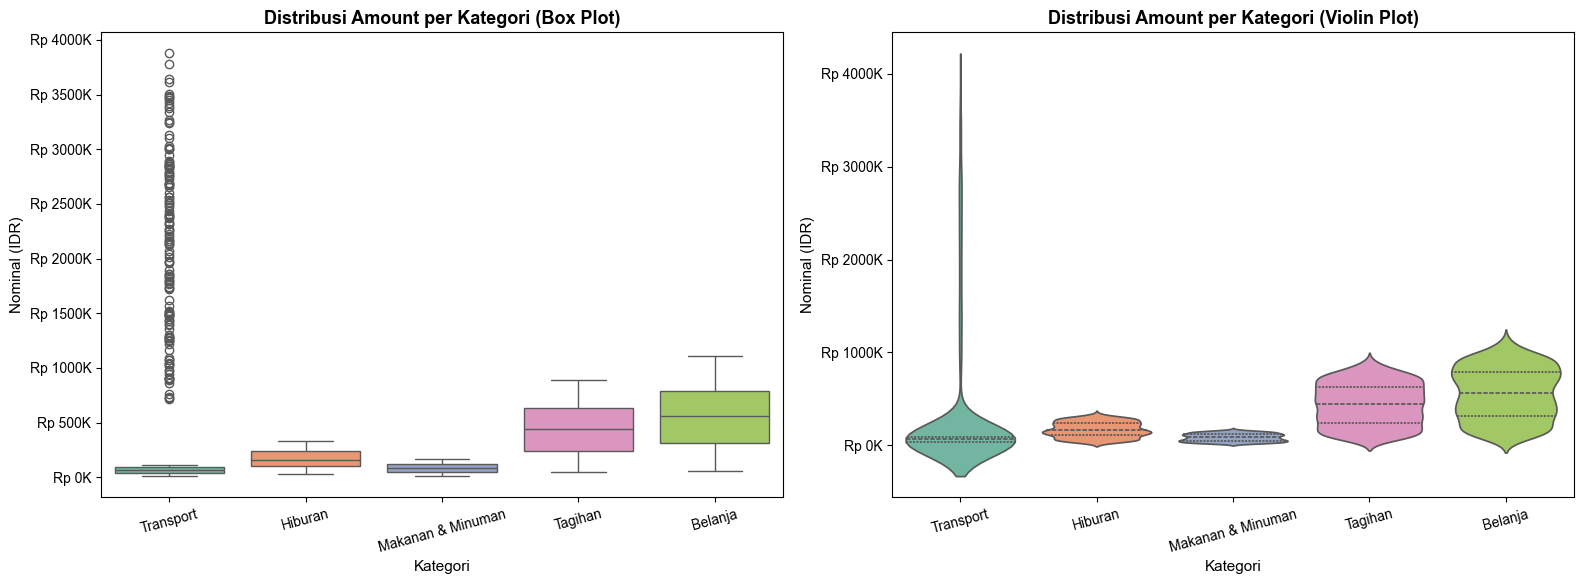


🔷 IQR Outlier Detection per Kategori:
Kategori                            Q1           Q3          IQR        Lower        Upper  Outlier
-----------------------------------------------------------------------------------------------
Transport                       36,630       91,140       54,510      -45,135      172,905      136
Hiburan                        104,125      236,760      132,635      -94,828      435,712        0
Makanan & Minuman               48,750      118,138       69,388      -55,331      222,219        0
Tagihan                        243,068      631,188      388,120     -339,112    1,213,368        0
Belanja                        315,875      792,510      476,635     -399,078    1,507,462        0

📋 Ringkasan Outlier:


,Kategori,Outlier Count,Persen (%)
0,Transport,136,11.33
1,Hiburan,0,0.00
2,Makanan & Minuman,0,0.00
3,Tagihan,0,0.00
4,Belanja,0,0.00



💡 Catatan: Outlier pada data sintetis ini bersumber dari logika simulasi nominal IDR.
   Tim ML tidak perlu menghapus outlier ini karena berasal dari distribusi yang disengaja.

✅ CELL 4A SELESAI: EDA distribusi amount dan deteksi outlier berhasil.


In [11]:
# ============================================================
# CELL 4A: EDA LANJUTAN – DISTRIBUSI AMOUNT & DETEKSI OUTLIER
# ============================================================

import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("  📊 EDA: DISTRIBUSI NOMINAL TRANSAKSI (AMOUNT)")
print("=" * 60)

# --- 1. STATISTIK DESKRIPTIF PER KATEGORI ---
print("\n🔷 Statistik Deskriptif Amount per Kategori (Rp):")
stats_per_cat = public_transactions_train.groupby('category')['amount'].describe()
stats_per_cat_display = stats_per_cat[['mean', '50%', 'min', 'max', 'std']].copy()
stats_per_cat_display.columns = ['Mean', 'Median', 'Min', 'Max', 'Std Dev']
# Format sebagai Rupiah
for col in stats_per_cat_display.columns:
    stats_per_cat_display[col] = stats_per_cat_display[col].apply(lambda x: f"Rp {x:,.0f}")
display(stats_per_cat_display)

# --- 2. BOX PLOT DISTRIBUSI AMOUNT ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Box plot
sns.boxplot(
    data=public_transactions_train,
    x='category',
    y='amount',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Distribusi Amount per Kategori (Box Plot)', fontsize=13, weight='bold')
axes[0].set_xlabel('Kategori', fontsize=11)
axes[0].set_ylabel('Nominal (IDR)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}K'))

# Violin plot
sns.violinplot(
    data=public_transactions_train,
    x='category',
    y='amount',
    palette='Set2',
    inner='quartile',
    ax=axes[1]
)
axes[1].set_title('Distribusi Amount per Kategori (Violin Plot)', fontsize=13, weight='bold')
axes[1].set_xlabel('Kategori', fontsize=11)
axes[1].set_ylabel('Nominal (IDR)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# --- 3. IQR OUTLIER DETECTION ---
print("\n🔷 IQR Outlier Detection per Kategori:")
print(f"{'Kategori':<25} {'Q1':>12} {'Q3':>12} {'IQR':>12} {'Lower':>12} {'Upper':>12} {'Outlier':>8}")
print("-" * 95)

outlier_summary = []
for cat in public_transactions_train['category'].unique():
    subset = public_transactions_train[public_transactions_train['category'] == cat]['amount']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((subset < lower) | (subset > upper)).sum()
    outlier_summary.append({'Kategori': cat, 'Outlier Count': n_outlier, 'Persen (%)': round(n_outlier/len(subset)*100, 2)})
    print(f"{cat:<25} {Q1:>12,.0f} {Q3:>12,.0f} {IQR:>12,.0f} {lower:>12,.0f} {upper:>12,.0f} {n_outlier:>8}")

print()
df_outlier_summary = pd.DataFrame(outlier_summary)
print("📋 Ringkasan Outlier:")
display(df_outlier_summary)
print("\n💡 Catatan: Outlier pada data ini bersumber dari logika simulasi nominal IDR.")
print("   Tim ML tidak perlu menghapus outlier ini karena berasal dari distribusi yang disengaja.")
print("\n✅ CELL 4A SELESAI: EDA distribusi amount dan deteksi outlier berhasil.")


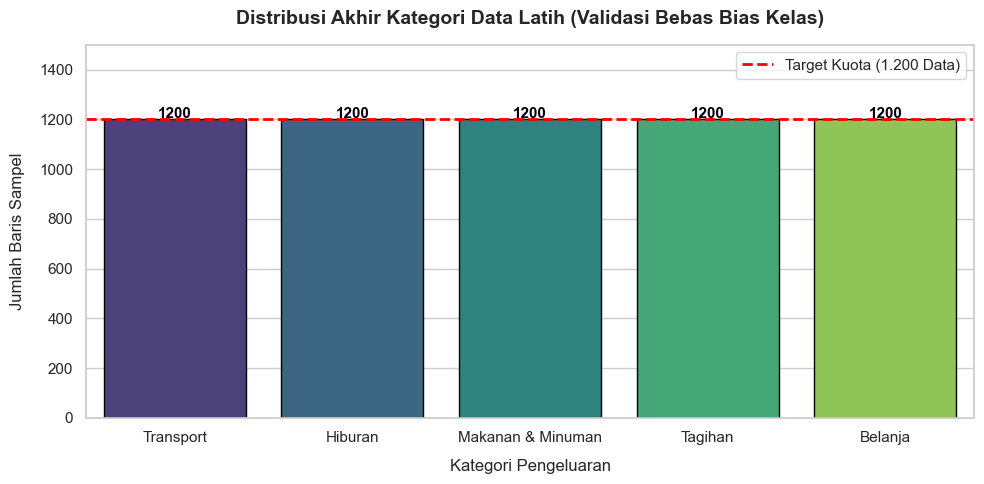

 TABEL FREKUENSI EKSRAK DATA LATIH FINAL
category
Transport            1200
Hiburan              1200
Makanan & Minuman    1200
Tagihan              1200
Belanja              1200
Name: count, dtype: int64


In [12]:
# 1. Menghitung distribusi final kategori pada data latih
final_distribution = public_transactions_train['category'].value_counts()

# 2. Mengatur estetika dan tema grafik
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# 3. Membuat Bar Chart
ax = sns.barplot(
    x=final_distribution.index, 
    y=final_distribution.values, 
    palette='viridis',
    edgecolor='black'
)

# 4. Menambahkan garis target horizontal (Force Balancing Target)
plt.axhline(y=1200, color='red', linestyle='--', linewidth=2, label='Target Kuota (1.200 Data)')

# 5. Menambahkan label angka di atas setiap batang grafik
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height() + 20), 
                ha='center', va='center', 
                fontsize=11, color='black', 
                weight='bold')

# 6. Atribut pelengkap grafik
plt.title('Distribusi Akhir Kategori Data Latih (Validasi Bebas Bias Kelas)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Kategori Pengeluaran', fontsize=12, labelpad=10)
plt.ylabel('Jumlah Baris Sampel', fontsize=12, labelpad=10)
plt.ylim(0, 1500) # Memberi ruang di atas batang untuk angka label
plt.legend(loc='upper right')

# 7. Tampilkan Grafik
plt.tight_layout()
plt.show()

# 8. Menampilkan tabel frekuensi presisi di bawah grafik
print("="*45)
print(" TABEL FREKUENSI EKSRAK DATA LATIH FINAL")
print("="*45)
print(final_distribution)
print("="*45)

# Cell 5: Feature Selection – Konfirmasi Fitur untuk Tim ML

### 🎯 Fungsi Utama Cell
Cell ini mendokumentasikan secara eksplisit fitur-fitur mana yang akan diteruskan ke tim Machine Learning. Walaupun dataset ini sederhana (4 kolom), cell ini penting sebagai kontrak formal antara tim Data dan tim ML.

### ⚙️ Alur Proses Logis:
1. **Identifikasi Feature vs Target:** Memisahkan mana yang menjadi input model (`X`) dan mana target prediksi (`y`).
2. **Correlation Check (Opsional):** Memeriksa korelasi antar fitur numerik untuk mendeteksi multikolinearitas.
3. **Final Schema Export:** Mendokumentasikan skema kolom final yang dikirim ke tim ML.

  🧪 FEATURE SELECTION – KONFIRMASI FITUR UNTUK TIM ML

🔷 Input Features (X)  : ['transaction_name', 'amount']
🔷 Target Label (y)    : category
🔷 Target Encoded (y') : category_encoded

📌 Catatan:
   - 'transaction_name' → diproses lebih lanjut oleh tim ML (TF-IDF / Embedding)
   - 'amount'           → fitur numerik siap pakai
   - 'category_encoded' → label untuk training (0–4)

🔷 Preview Dataset yang Dikirim ke Tim ML:


,transaction_name,amount,category,category_encoded
0,GOPAY GO-RIDE - <ID>,94350.0,Transport,4
1,TIKET BIOSKOP XXI - <ID>,116250.0,Hiburan,1
2,M4K4N D1 R3ST0R4N - <ID>,44000.0,Makanan & Minuman,2
3,TIKET KERETA KAI - <ID>,31000.0,Transport,4
4,PEMBAYARAN PLN*REK - <ID>,201000.0,Tagihan,3



   Shape: 6000 baris x 4 kolom

🔷 Dokumentasi Label Encoding (Harus disampaikan ke Tim ML):
   0 → Belanja
   1 → Hiburan
   2 → Makanan & Minuman
   3 → Tagihan
   4 → Transport

🔷 Korelasi Fitur Numerik:
                    amount  category_encoded
amount            1.000000         -0.091166
category_encoded -0.091166          1.000000


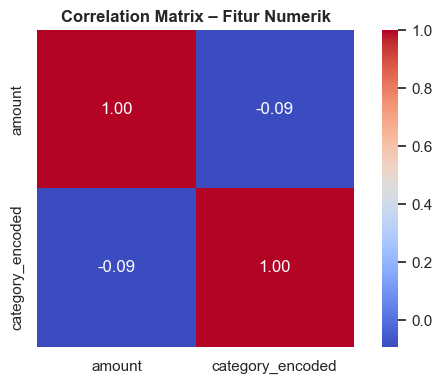


✅ CELL 5 SELESAI: Feature selection terdokumentasi dan siap dikirim ke Tim ML.


In [13]:
# ============================================================
# CELL 5: FEATURE SELECTION
# ============================================================

print("=" * 60)
print("  🧪 FEATURE SELECTION – KONFIRMASI FITUR UNTUK TIM ML")
print("=" * 60)

# --- 1. DEFINISI FEATURE & TARGET ---
FEATURE_COLUMNS = ['transaction_name', 'amount']
TARGET_COLUMN   = 'category'
TARGET_ENCODED  = 'category_encoded'

print(f"\n🔷 Input Features (X)  : {FEATURE_COLUMNS}")
print(f"🔷 Target Label (y)    : {TARGET_COLUMN}")
print(f"🔷 Target Encoded (y') : {TARGET_ENCODED}")
print("\n📌 Catatan:")
print("   - 'transaction_name' → diproses lebih lanjut oleh tim ML (TF-IDF / Embedding)")
print("   - 'amount'           → fitur numerik siap pakai")
print("   - 'category_encoded' → label untuk training (0–4)")

# --- 2. SAMPLE FEATURE PREVIEW ---
print("\n🔷 Preview Dataset yang Dikirim ke Tim ML:")
df_for_ml = public_transactions_train[FEATURE_COLUMNS + [TARGET_COLUMN, TARGET_ENCODED]].copy()
display(df_for_ml.head(5))
print(f"\n   Shape: {df_for_ml.shape[0]} baris x {df_for_ml.shape[1]} kolom")

# --- 3. LABEL ENCODER MAPPING DOKUMENTASI ---
print("\n🔷 Dokumentasi Label Encoding (Harus disampaikan ke Tim ML):")
for i, label in enumerate(le.classes_):
    print(f"   {i} → {label}")

# --- 4. CORRELATION CHECK (NUMERIK) ---
print("\n🔷 Korelasi Fitur Numerik:")
numeric_cols = public_transactions_train.select_dtypes(include='number').columns.tolist()
if len(numeric_cols) > 1:
    corr = public_transactions_train[numeric_cols].corr()
    print(corr)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax, square=True)
    ax.set_title('Correlation Matrix – Fitur Numerik', fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("   Hanya ada 1 fitur numerik ('amount'), tidak ada multikolinearitas.")

print("\n✅ CELL 5 SELESAI: Feature selection terdokumentasi dan siap dikirim ke Tim ML.")


# Cell 6: Data Splitting – Validasi Proporsi Train/Test Split

### 🎯 Fungsi Utama Cell
Cell ini memvalidasi secara eksplisit bahwa rasio pembagian antara dataset latih (`public_transactions_train.csv`) dan dataset uji (`public_transactions_test_fixed.csv`) sudah memenuhi standar praktik terbaik Data Science (umumnya 70:30 atau 80:20).

### ⚙️ Alur Proses Logis:
1. **Load Final Files:** Membaca kembali file CSV yang sudah disimpan untuk memastikan integritas file.
2. **Proporsi Split Check:** Menghitung rasio train:test secara aktual.
3. **Distribusi Per Kelas Check:** Memastikan distribusi kategori di test set representatif.
4. **Final Report:** Ringkasan lengkap siap diserahkan ke tim ML.

  ✂️  DATA SPLITTING – VALIDASI PROPORSI TRAIN/TEST

🔷 Ukuran Dataset:
   Training Set : 6,000 baris (83.1%)
   Test Set     : 1,220 baris (16.9%)
   Total        : 7,220 baris

   ✅ Rasio Split VALID → 83:17 (memenuhi standar 70-85% train)

🔷 Distribusi Kategori Train vs Test:


,Train,Test,Train (%),Test (%)
category,,,,
Transport,1200,216,20.0,17.7
Hiburan,1200,300,20.0,24.6
Makanan & Minuman,1200,218,20.0,17.9
Tagihan,1200,300,20.0,24.6
Belanja,1200,186,20.0,15.2


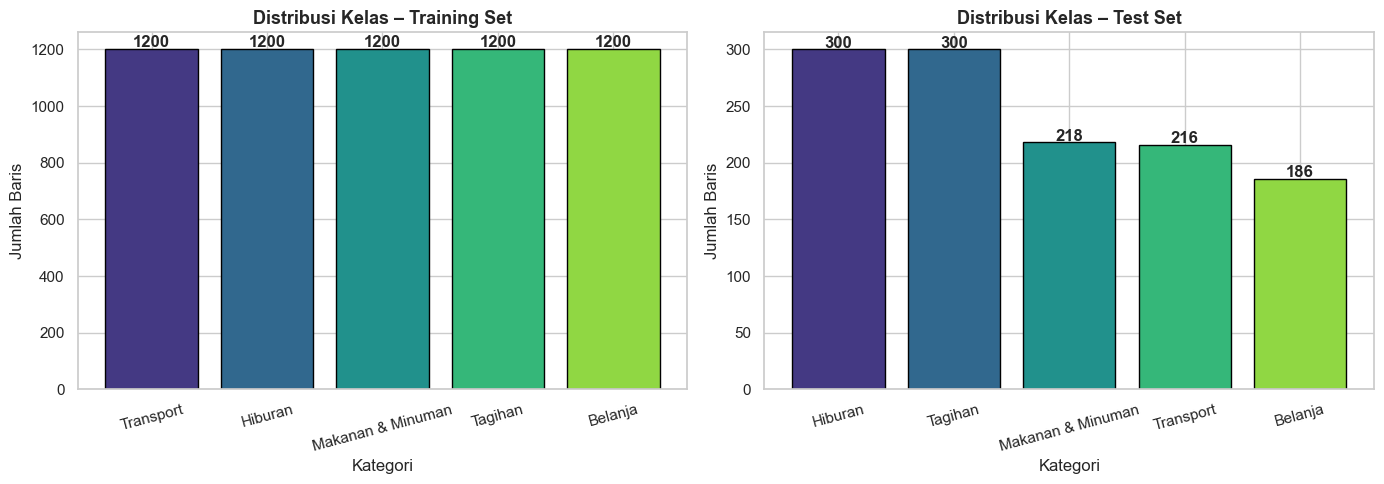


  📦 FINAL DATASET REPORT (UNTUK TIM ML)
  📁 Train File : public_transactions_train.csv
     → 6000 baris | 4 kolom | Balanced (1200/kelas)
  📁 Test File  : public_transactions_test_fixed.csv
     → 1220 baris | 4 kolom
  📐 Split Ratio: 83% Train / 17% Test
  🏷️  Kolom Final: transaction_name, amount, category, category_encoded
  🔢 Jumlah Kelas: 5 kategori
  🔢 Label Map   : {'Belanja': np.int64(0), 'Hiburan': np.int64(1), 'Makanan & Minuman': np.int64(2), 'Tagihan': np.int64(3), 'Transport': np.int64(4)}

🎉 PIPELINE SELESAI: Dataset siap diserahkan ke Tim Machine Learning!


In [14]:
# ============================================================
# CELL 6: DATA SPLITTING – VALIDASI PROPORSI TRAIN/TEST
# ============================================================

print("=" * 60)
print("  ✂️  DATA SPLITTING – VALIDASI PROPORSI TRAIN/TEST")
print("=" * 60)

# --- 1. LOAD FINAL FILES ---
df_final_train = pd.read_csv(str(PATH_OUTPUT_TRAIN))
df_final_test  = pd.read_csv(str(PATH_OUTPUT_TEST))

n_train = len(df_final_train)
n_test  = len(df_final_test)
n_total = n_train + n_test
pct_train = n_train / n_total * 100
pct_test  = n_test  / n_total * 100

print(f"\n🔷 Ukuran Dataset:")
print(f"   Training Set : {n_train:,} baris ({pct_train:.1f}%)")
print(f"   Test Set     : {n_test:,} baris ({pct_test:.1f}%)")
print(f"   Total        : {n_total:,} baris")

# Evaluasi
if 70 <= pct_train <= 85:
    print(f"\n   ✅ Rasio Split VALID → {pct_train:.0f}:{pct_test:.0f} (memenuhi standar 70-85% train)")
else:
    print(f"\n   ⚠️ Rasio Split PERLU DITINJAU → {pct_train:.0f}:{pct_test:.0f}")

# --- 2. DISTRIBUSI KELAS DI TRAIN vs TEST ---
print("\n🔷 Distribusi Kategori Train vs Test:")
cat_train = df_final_train['category'].value_counts().rename('Train')
cat_test  = df_final_test['category'].value_counts().rename('Test')
cat_compare = pd.concat([cat_train, cat_test], axis=1).fillna(0).astype(int)
cat_compare['Train (%)'] = (cat_compare['Train'] / n_train * 100).round(1)
cat_compare['Test (%)']  = (cat_compare['Test']  / n_test  * 100).round(1)
display(cat_compare)

# --- 3. VISUALISASI PERBANDINGAN ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('viridis', len(cat_train))

axes[0].bar(cat_train.index, cat_train.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Kelas – Training Set', fontsize=13, weight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Baris')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(cat_train.values):
    axes[0].text(i, v + 10, str(v), ha='center', weight='bold')

axes[1].bar(cat_test.index if cat_test is not None else cat_train.index,
            cat_test.values if cat_test is not None else [0]*len(cat_train),
            color=colors, edgecolor='black')
axes[1].set_title('Distribusi Kelas – Test Set', fontsize=13, weight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah Baris')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(cat_test.values):
    axes[1].text(i, v + 1, str(v), ha='center', weight='bold')

plt.tight_layout()
plt.show()

# --- 4. FINAL REPORT ---
print("\n" + "=" * 60)
print("  📦 FINAL DATASET REPORT (UNTUK TIM ML)")
print("=" * 60)
print(f"  📁 Train File : public_transactions_train.csv")
print(f"     → {n_train} baris | {df_final_train.shape[1]} kolom | Balanced (1200/kelas)")
print(f"  📁 Test File  : public_transactions_test_fixed.csv")
print(f"     → {n_test} baris | {df_final_test.shape[1]} kolom")
print(f"  📐 Split Ratio: {pct_train:.0f}% Train / {pct_test:.0f}% Test")
print(f"  🏷️  Kolom Final: transaction_name, amount, category, category_encoded")
print(f"  🔢 Jumlah Kelas: {df_final_train['category'].nunique()} kategori")
print(f"  🔢 Label Map   : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("=" * 60)
print("\n🎉 PIPELINE SELESAI: Dataset siap diserahkan ke Tim Machine Learning!")
